In [1]:
!pip install pandas

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
print("[*] Loading and parsing data...")
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

[*] Loading and parsing data...


In [2]:
import pandas as pd

In [13]:
df = pd.read_csv(filepath_or_buffer="ecommerce_sales_analytics_5000.csv")

In [34]:
# Convert date to standard datetime object
df['order_date'] = pd.to_datetime(df['order_date'])  

In [35]:
def generate_kpis(df):
    """Calculates high-level business metrics."""
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_delivery_time = df['delivery_days'].mean()
avg_customer_rating = df['customer_rating'].mean()

In [36]:
print("\n" + "="*40)
print("      EXECUTIVE MIS KPI SUMMARY      ")
print("="*40)
print(f"Total Generated Revenue : ${total_revenue:,.2f}")
print(f"Total Unique Orders     : {total_orders:,}")
print(f"Average Order Value     : ${avg_order_value:,.2f}")
print(f"Average Delivery Time   : {avg_delivery_time:.1f} Days")
print(f"Average Customer Rating : {avg_customer_rating:.2f} / 5.0")
print("="*40)


      EXECUTIVE MIS KPI SUMMARY      
Total Generated Revenue : $5,109,775.74
Total Unique Orders     : 5,000
Average Order Value     : $1,021.96
Average Delivery Time   : 6.1 Days
Average Customer Rating : 2.97 / 5.0


In [39]:
def aggregate_insights(df):
    """Performs grouped business performance analysis."""
print("\n[+] Top Performing Product Categories by Revenue:")
category_perf = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
print(category_perf.apply(lambda x: f"${x:,.2f}"))


[+] Top Performing Product Categories by Revenue:
product_category
Electronics    $1,829,899.22
Clothing       $1,531,931.72
Home             $982,083.92
Beauty           $765,860.88
Name: revenue, dtype: object


In [40]:
print("\n[+] Regional Sales Distribution:")
region_perf = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
print(region_perf.apply(lambda x: f"${x:,.2f}"))


[+] Regional Sales Distribution:
region
West     $1,345,582.16
North    $1,281,508.45
South    $1,246,640.90
East     $1,236,044.23
Name: revenue, dtype: object


In [41]:
print("\n[+] Preferred Customer Payment Methods:")
payment_perf = df['payment_method'].value_counts()
print(payment_perf)


[+] Preferred Customer Payment Methods:
payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64


In [43]:
def generate_plots(df):
    """Generates and saves production charts."""
print("\n[*] Exporting analytical visualization charts...")
sns.set_theme(style="whitegrid")


[*] Exporting analytical visualization charts...


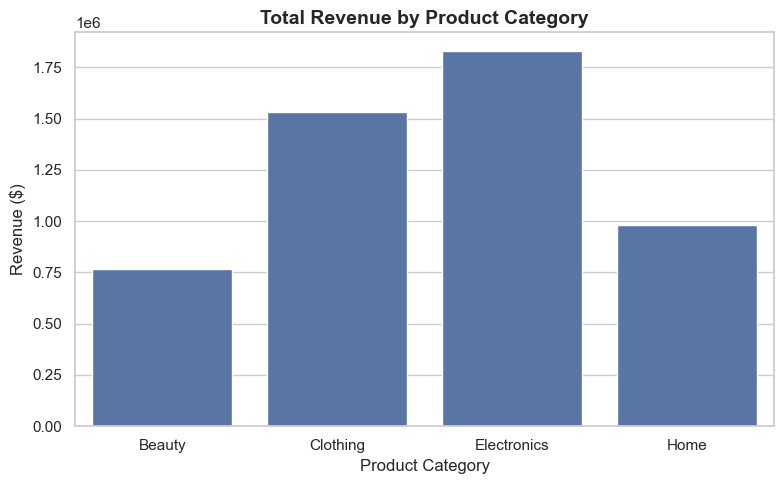

In [51]:
# Chart 1: Revenue by Product Category
plt.figure(figsize=(8, 5))
cat_rev = df.groupby('product_category')['revenue'].sum().reset_index()
sns.barplot(data=cat_rev, x='product_category', y='revenue')
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=300)
plt.show()

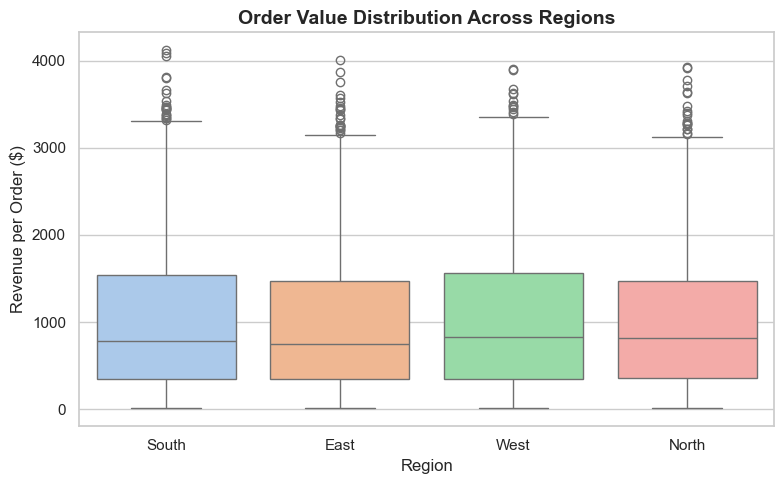

In [54]:
# Chart 2: Regional Performance Matrix
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='revenue', hue='region', palette='pastel', legend=False)
plt.title('Order Value Distribution Across Regions', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Revenue per Order ($)')
plt.tight_layout()
plt.savefig('regional_revenue_distribution.png', dpi=300)
plt.show()

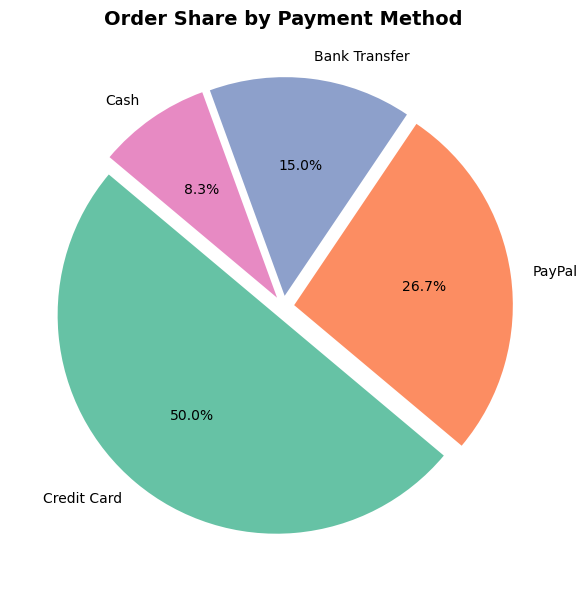

In [10]:
# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('Set2', len(payment_counts)), explode=[0.05]*len(payment_counts))
plt.title('Order Share by Payment Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()